In [70]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# XGBoost
from xgboost import XGBClassifier

# LightGBM
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [71]:
!pip install xgboost lightgbm -q

In [72]:
train_path = "/kaggle/input/competitions/playground-series-s6e8/train.csv"
train_df = pd.read_csv(train_path)
train_df.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [73]:
test_path = "/kaggle/input/competitions/playground-series-s6e8/test.csv"
test_df = pd.read_csv(train_path)
test_df.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [74]:
df = train_df

In [75]:
print("Dataset Shape:", df.shape)

Dataset Shape: (691369, 14)


In [76]:
print("\nColumns:")
print(df.columns.tolist())


Columns:
['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact', 'addicted_label']


In [77]:
print("\nData Types:")
print(df.dtypes)


Data Types:
id                           int64
age                        float64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day      float64
app_opens_per_day          float64
weekend_screen_time        float64
gender                      object
stress_level                object
academic_work_impact        object
addicted_label               int64
dtype: object


In [78]:
print("Target value counts:")
print(df["addicted_label"].value_counts())

print("\nTarget percentages:")
print(df["addicted_label"].value_counts(normalize=True) * 100)

Target value counts:
addicted_label
1    490474
0    200895
Name: count, dtype: int64

Target percentages:
addicted_label
1    70.942435
0    29.057565
Name: proportion, dtype: float64


# Handle missing values and categorical variables.

In [79]:
categorical_cols = df.select_dtypes(
    include = ["object","category"]
).columns.tolist()

In [80]:
numeric_cols = df.select_dtypes(
    include = ["int64","float64"]
).columns.tolist()

numeric_features = [
    col for col in numeric_cols
    if col not in ["id","addicted_label"]
]

In [81]:
print("Categorical columns:") 
print(categorical_cols) 
print("\nNumerical features:") 
print(numeric_features)

Categorical columns:
['gender', 'stress_level', 'academic_work_impact']

Numerical features:
['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']


In [82]:
print(df.isnull().sum())

id                              0
age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224
addicted_label                  0
dtype: int64


In [83]:
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary.sort_values(
    by='Missing Percentage',
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage
social_media_hours,133995,19.381112
gaming_hours,126821,18.343461
weekend_screen_time,112063,16.208855
daily_screen_time_hours,95854,13.864376
app_opens_per_day,80710,11.673940
notifications_per_day,67584,9.775388
stress_level,55148,7.976638
work_study_hours,51518,7.451592
sleep_hours,44480,6.433612
academic_work_impact,44224,6.396584


In [84]:
for col in numeric_features:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [85]:
print(df.isnull().sum())

id                         0
age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
gender                     0
stress_level               0
academic_work_impact       0
addicted_label             0
dtype: int64


In [86]:
df.duplicated().sum()

np.int64(0)

# EDA

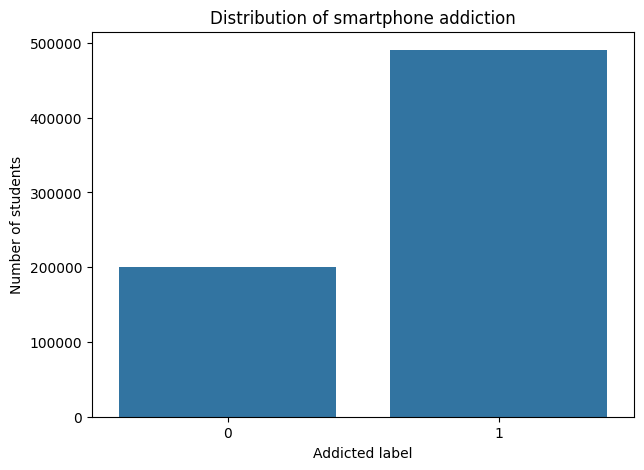

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.countplot(data=df,x="addicted_label")

plt.title("Distribution of smartphone addiction")
plt.xlabel("Addicted label")
plt.ylabel("Number of students")
plt.show()

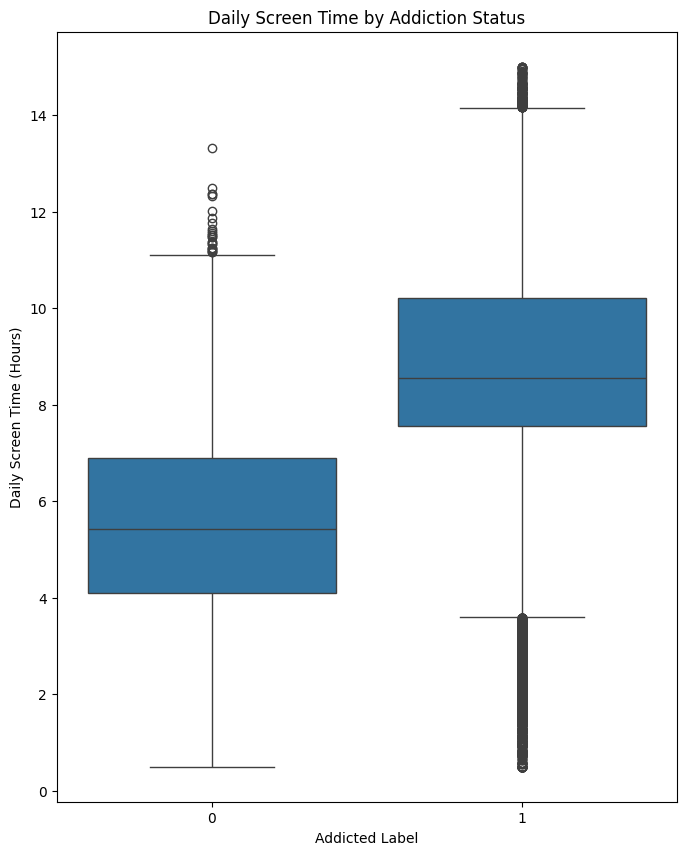

In [88]:
plt.figure(figsize=(8,10))


sns.boxplot(
    data = df,
    x = "addicted_label",
    y = "daily_screen_time_hours"
)

plt.title("Daily Screen Time by Addiction Status")
plt.xlabel("Addicted Label")
plt.ylabel("Daily Screen Time (Hours)")
plt.show()

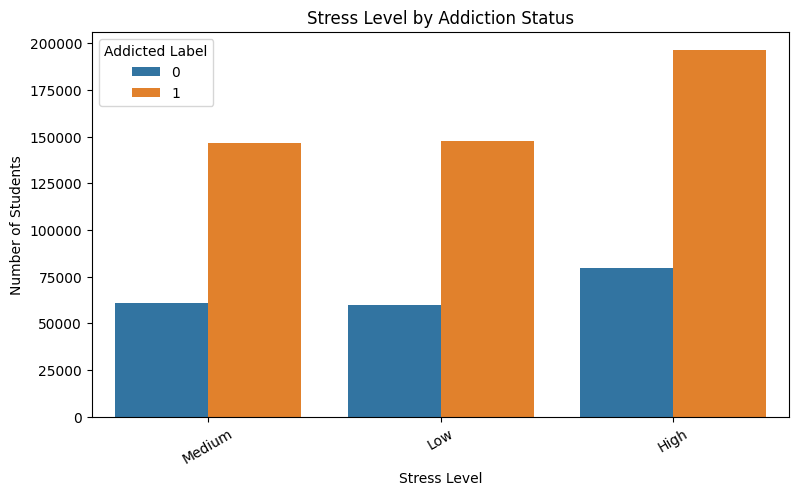

In [89]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="stress_level",
    hue="addicted_label"
)

plt.title("Stress Level by Addiction Status")
plt.xlabel("Stress Level")
plt.ylabel("Number of Students")
plt.legend(title="Addicted Label")
plt.xticks(rotation=30)

plt.show()

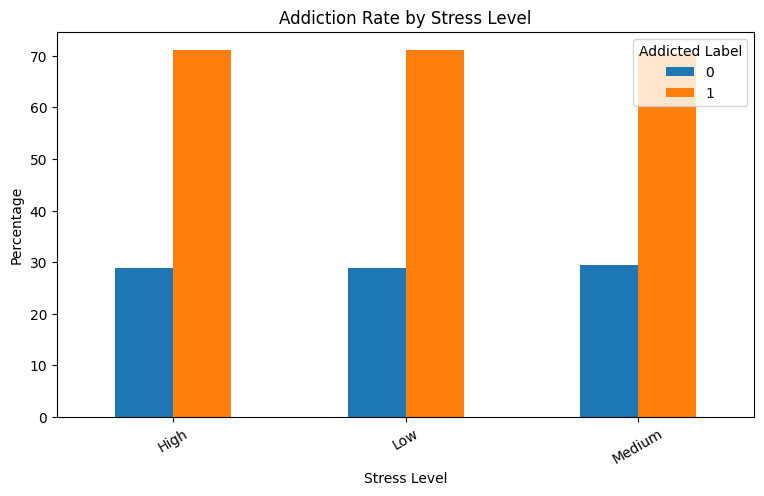

In [90]:
stress_addiction = pd.crosstab(
    df["stress_level"],
    df["addicted_label"],
    normalize="index"
) * 100

stress_addiction.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Addiction Rate by Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Percentage")
plt.legend(title="Addicted Label")

plt.xticks(rotation=30)
plt.show()

EDA revealed that smartphone addiction is moderately imbalanced, with approximately 70.9% of observations classified as addicted. Daily screen time showed a clear relationship with addiction status, with addicted individuals generally reporting substantially higher screen time. The analysis of stress level showed relatively similar addiction proportions across categories, although the high-stress group showed a slightly higher proportion of addiction. These findings suggest that screen-time-related variables may be particularly useful for predicting smartphone addiction.

# Creating train/validation/test data appropriately.

In [93]:
x = train_df.drop(columns=["id", "addicted_label"])
y = train_df["addicted_label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (691369, 12)
y shape: (691369,)


In [94]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    x,
    y,
    test_size = .3,
    random_state = 42,
    stratify = y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)
print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (483958, 12) (483958,)
Validation set: (103705, 12) (103705,)
Test set: (103706, 12) (103706,)


In [96]:
print("Training target distribution")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

      

Training target distribution
addicted_label
1    70.94252
0    29.05748
Name: proportion, dtype: float64

Validation target distribution:
addicted_label
1    70.942578
0    29.057422
Name: proportion, dtype: float64

Test target distribution:
addicted_label
1    70.941893
0    29.058107
Name: proportion, dtype: float64


# Preprocessing

In [98]:
print(numeric_features)
print(categorical_cols)

['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
['gender', 'stress_level', 'academic_work_impact']


In [105]:
numerical_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median"))
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_cols)
    ]
)
print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [106]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['age', 'daily_screen_time_hours',
                                  'social_media_hours', 'gaming_hours',
                                  'work_study_hours', 'sleep_hours',
                                  'notifications_per_day', 'app_opens_per_day',
                                  'weekend_screen_time']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'stress_level',
                                  'academic_work_impact'])])

In [107]:
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Training processed shape:", X_train_processed.shape)
print("Validation processed shape:", X_val_processed.shape)
print("Test processed shape:", X_test_processed.shape)

Training processed shape: (483958, 17)
Validation processed shape: (103705, 17)
Test processed shape: (103706, 17)


# Decision Tree

In [108]:
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train_processed, y_train)

DecisionTreeClassifier(random_state=42)

In [114]:
y_val_pred_dt = decision_tree.predict(X_val_processed)

print("Decision Tree validation predictions generated.")

Decision Tree validation predictions generated.


In [115]:
print(pd.Series(y_val_pred_dt).value_counts())

1    73436
0    30269
Name: count, dtype: int64


In [116]:
accuracy_dt = accuracy_score(y_val, y_val_pred_dt)
precision_dt = precision_score(y_val, y_val_pred_dt)
recall_dt = recall_score(y_val, y_val_pred_dt)
f1_dt = f1_score(y_val, y_val_pred_dt)

print("Decision Tree Results")
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)

Decision Tree Results
Accuracy : 0.8195168988959066
Precision: 0.8734816711149844
Recall   : 0.8718788653137786
F1 Score : 0.872679532267171


# Random Forest.

In [117]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=1
)

random_forest.fit(X_train_processed,y_train)

RandomForestClassifier(n_jobs=1, random_state=42)

In [118]:
y_val_pred_rf = random_forest.predict(X_val_processed)

print("Random Forest validation predictions generated.")
print("Number of predictions:", len(y_val_pred_rf))

Random Forest validation predictions generated.
Number of predictions: 103705


In [119]:
accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
precision_rf = precision_score(y_val, y_val_pred_rf)
recall_rf = recall_score(y_val, y_val_pred_rf)
f1_rf = f1_score(y_val, y_val_pred_rf)

print("Random Forest Results")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Random Forest Results
Accuracy : 0.8688394966491491
Precision: 0.9010070479986091
Recall   : 0.9157276644329967
F1 Score : 0.9083077171978644


# Gradient Boosting.

In [120]:
gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=.1,
    max_depth=3,
    random_state=42
)
gradient_boosting.fit(X_train_processed,y_train)

GradientBoostingClassifier(random_state=42)

In [121]:
y_val_pred_gb = gradient_boosting.predict(X_val_processed)

print("Gradient Boosting validation predictions generated.")
print("Number of predictions:", len(y_val_pred_gb))

Gradient Boosting validation predictions generated.
Number of predictions: 103705


In [122]:
accuracy_gb = accuracy_score(y_val, y_val_pred_gb)
precision_gb = precision_score(y_val, y_val_pred_gb)
recall_gb = recall_score(y_val, y_val_pred_gb)
f1_gb = f1_score(y_val, y_val_pred_gb)

print("Gradient Boosting Results")
print("Accuracy :", accuracy_gb)
print("Precision:", precision_gb)
print("Recall   :", recall_gb)
print("F1 Score :", f1_gb)

Gradient Boosting Results
Accuracy : 0.8619738681837905
Precision: 0.9083254089662491
Recall   : 0.8958557040138098
F1 Score : 0.9020474639367148


In [124]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=.1,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)
xgb_model.fit(X_train_processed,y_train)
y_val_pred_xgb = xgb_model.predict(X_val_processed)

In [125]:
accuracy_xgb = accuracy_score(y_val, y_val_pred_xgb)
precision_xgb = precision_score(y_val, y_val_pred_xgb)
recall_xgb = recall_score(y_val, y_val_pred_xgb)
f1_xgb = f1_score(y_val, y_val_pred_xgb)

print("XGBoost Results")
print("Accuracy :", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall   :", recall_xgb)
print("F1 Score :", f1_xgb)

XGBoost Results
Accuracy : 0.8795525770213587
Precision: 0.9118456185775549
Recall   : 0.9190713732313004
F1 Score : 0.9154442376036555


# LightGBM.

In [133]:
light_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=.1,
    max_depth=-1,
    random_state=42,
    n_jobs=-1
)
light_model.fit(X_train_processed,y_train)
y_val_pred_lgbm = light_model.predict(X_val_processed)

[LightGBM] [Info] Number of positive: 343332, number of negative: 140626
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010136 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1956
[LightGBM] [Info] Number of data points in the train set: 483958, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.709425 -> initscore=0.892594
[LightGBM] [Info] Start training from score 0.892594


In [134]:
accuracy_lgbm = accuracy_score(y_val, y_val_pred_lgbm)
precision_lgbm = precision_score(y_val, y_val_pred_lgbm)
recall_lgbm = recall_score(y_val, y_val_pred_lgbm)
f1_lgbm = f1_score(y_val, y_val_pred_lgbm)

print("LightGBM Results")
print("Accuracy :", accuracy_lgbm)
print("Precision:", precision_lgbm)
print("Recall   :", recall_lgbm)
print("F1 Score :", f1_lgbm)

LightGBM Results
Accuracy : 0.8881538980762741
Precision: 0.9181646423751687
Recall   : 0.9247665520381673
F1 Score : 0.9214537722369321


# Comparing all models using accuracy, precision, recall, F1-score, and confusion matrix.

In [135]:
predictions = {
    "Decision Tree": y_val_pred_dt,
    "Random Forest": y_val_pred_rf,
    "Gradient Boosting": y_val_pred_gb,
    "XGBoost": y_val_pred_xgb,
    "LightGBM": y_val_pred_lgbm
}
results = []

for model_name, y_pred in predictions.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-Score": f1_score(y_val, y_pred)
    })

results_df = pd.DataFrame(results)

# Sort by F1-score
results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

print(results_df)

               Model  Accuracy  Precision    Recall  F1-Score
0           LightGBM  0.888154   0.918165  0.924767  0.921454
1            XGBoost  0.879553   0.911846  0.919071  0.915444
2      Random Forest  0.868839   0.901007  0.915728  0.908308
3  Gradient Boosting  0.861974   0.908325  0.895856  0.902047
4      Decision Tree  0.819517   0.873482  0.871879  0.872680


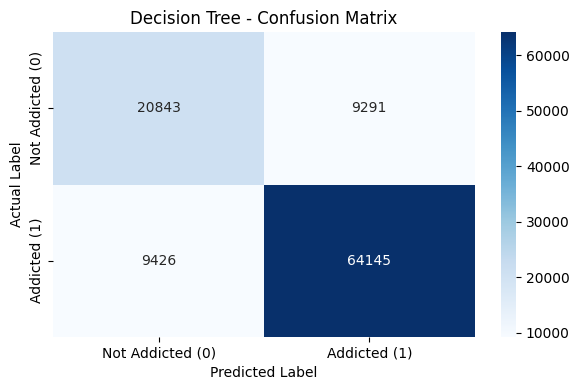

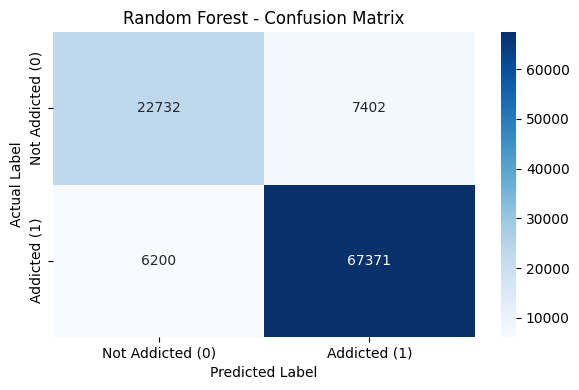

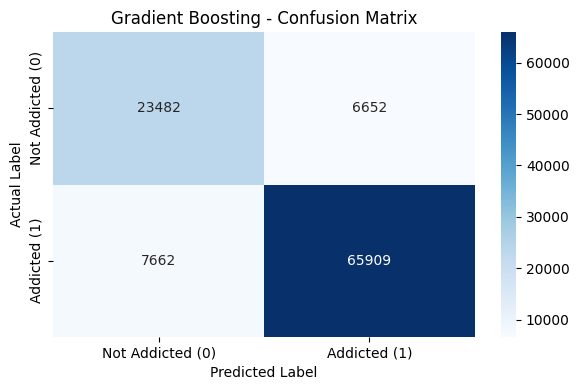

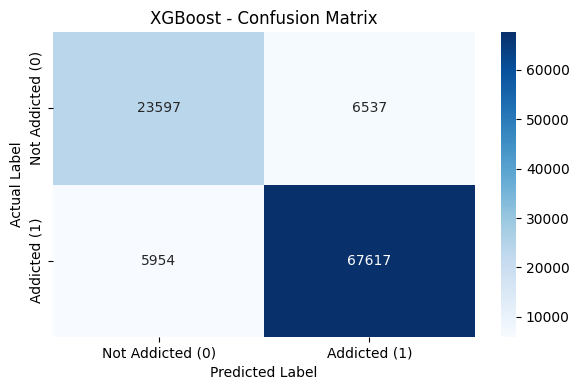

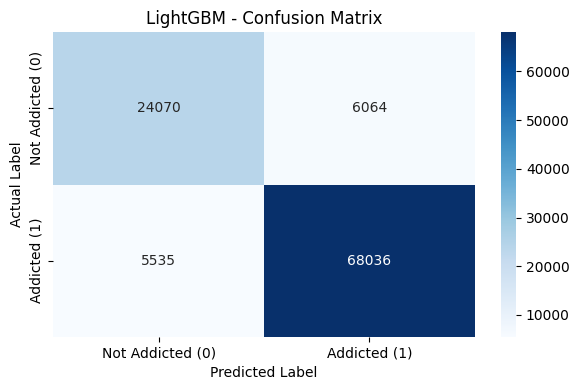

In [139]:
for model_name, y_pred in predictions.items():

    cm = confusion_matrix(y_val, y_pred)

    plt.figure(figsize=(6, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Not Addicted (0)", "Addicted (1)"],
        yticklabels=["Not Addicted (0)", "Addicted (1)"]
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()

# feature importance

In [140]:
feature_names = preprocessor.get_feature_names_out()
importance_values = light_model.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})
# Sort from most to least important
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)
print(feature_importance_df)

                          Feature  Importance
0          num__app_opens_per_day         752
1      num__notifications_per_day         645
2    num__daily_screen_time_hours         383
3         num__social_media_hours         356
4        num__weekend_screen_time         348
5           num__work_study_hours         191
6               num__gaming_hours         157
7                        num__age          95
8                num__sleep_hours          66
9                cat__gender_Male           4
10       cat__stress_level_Medium           2
11  cat__academic_work_impact_Yes           1
12             cat__gender_Female           0
13         cat__stress_level_High           0
14              cat__gender_Other           0
15          cat__stress_level_Low           0
16   cat__academic_work_impact_No           0


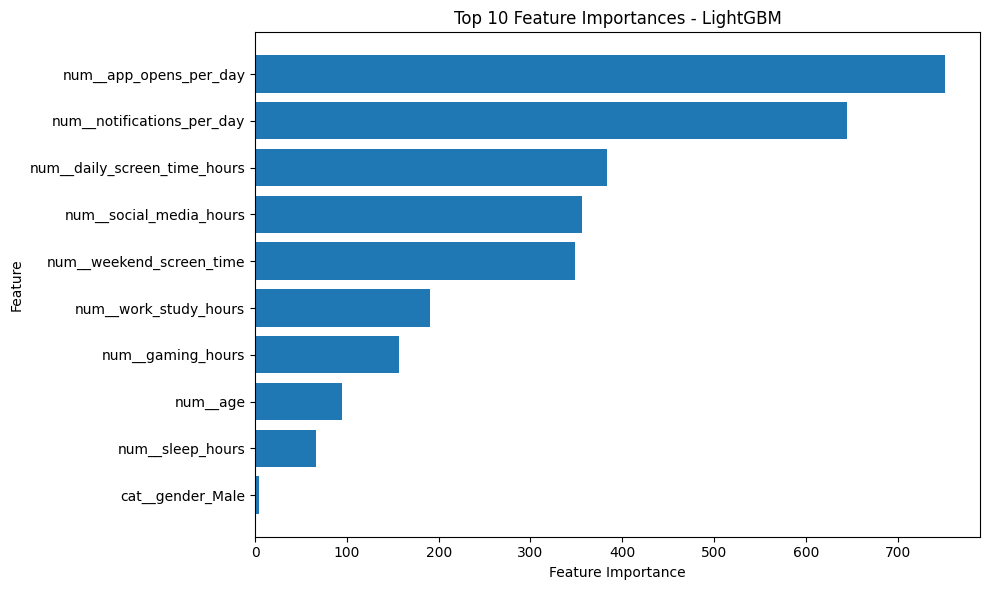

In [144]:
top_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - LightGBM")
plt.tight_layout()
plt.show()

Feature importance was analyzed using the selected LightGBM model. The importance scores indicate which features contributed most to the model's predictions of smartphone addiction. Features related to screen usage, such as daily screen time, social media usage, gaming hours, and app usage, are expected to be among the most influential predictors. This suggests that patterns of smartphone usage play an important role in predicting addiction. The importance plot also provides an interpretable view of which variables the model relied on most heavily.

# Generating predictions for unseen/test data

In [147]:
X_kaggle_test = test_df.drop(columns=["id"])

X_kaggle_test_processed = preprocessor.transform(X_kaggle_test)

In [148]:
test_predictions = light_model.predict(X_kaggle_test_processed)

print("Number of predictions:", len(test_predictions))
print("First 10 predictions:", test_predictions[:10])

Number of predictions: 691369
First 10 predictions: [1 0 0 0 1 0 0 1 0 1]


# Creating the submission file

In [149]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "addicted_label": test_predictions
})

submission.to_csv(
    "lightgbm_submission.csv",
    index=False
)

print("Submission file created successfully.")
print(submission.head())

Submission file created successfully.
   id  addicted_label
0   0               1
1   1               0
2   2               0
3   3               0
4   4               1


# Final unbiased evaluation of our selected LightGBM model

In [150]:
y_test_pred_lgbm = light_model.predict(X_test_processed)

# Calculate evaluation metrics
accuracy_test_lgbm = accuracy_score(y_test, y_test_pred_lgbm)
precision_test_lgbm = precision_score(y_test, y_test_pred_lgbm)
recall_test_lgbm = recall_score(y_test, y_test_pred_lgbm)
f1_test_lgbm = f1_score(y_test, y_test_pred_lgbm)

print("Final LightGBM Test Results")
print("----------------------------")
print("Accuracy :", accuracy_test_lgbm)
print("Precision:", precision_test_lgbm)
print("Recall   :", recall_test_lgbm)
print("F1-Score :", f1_test_lgbm)

# Confusion matrix
cm_lgbm_test = confusion_matrix(y_test, y_test_pred_lgbm)

print("\nConfusion Matrix:")
print(cm_lgbm_test)

# Detailed classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_test_pred_lgbm,
    target_names=["Not Addicted (0)", "Addicted (1)"]
))

Final LightGBM Test Results
----------------------------
Accuracy : 0.8873449945036931
Precision: 0.917136232509234
Recall   : 0.924752959725979
F1-Score : 0.9209288474684101

Confusion Matrix:
[[23988  6147]
 [ 5536 68035]]

Classification Report:
                  precision    recall  f1-score   support

Not Addicted (0)       0.81      0.80      0.80     30135
    Addicted (1)       0.92      0.92      0.92     73571

        accuracy                           0.89    103706
       macro avg       0.86      0.86      0.86    103706
    weighted avg       0.89      0.89      0.89    103706



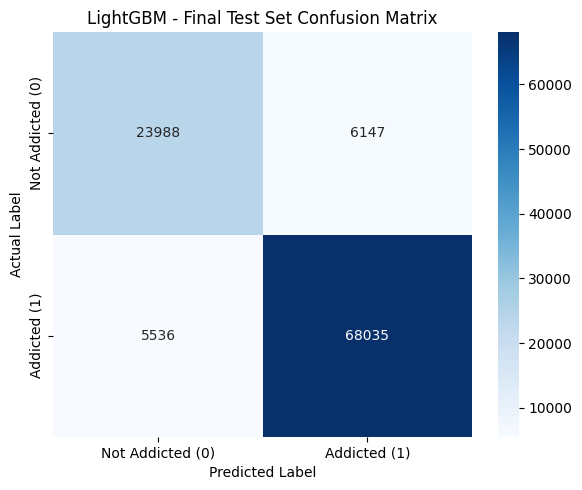

In [151]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lgbm_test,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Addicted (0)", "Addicted (1)"],
    yticklabels=["Not Addicted (0)", "Addicted (1)"]
)

plt.title("LightGBM - Final Test Set Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()